# 🎯 RFM Customer Segmentation — Complete Analysis
## Online Retail Dataset | Step-by-Step Notebook

This notebook follows the **CRISP-DM** methodology:
1. Data Loading & Overview
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. RFM Feature Engineering
5. K-Means Clustering (Elbow Method)
6. Segment Analysis & Visualisation
7. 📅 Returning Customer Analysis — All 12 Months


## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['figure.facecolor'] = 'white'
sns.set_palette('Set2')
print(" Libraries imported successfully")


 Libraries imported successfully


---
## Step 1 — Load the Dataset
We load the **dirty** dataset which contains real-world data quality issues.

In [2]:
df = pd.read_csv('online_retail_dirty.csv')
print(f"Shape: {df.shape}")
df.head(10)


Shape: (15847, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV020152,SC2551,VINTAGE UNION JACK MEMOBOARD,1,2024-12-07 00:00:00,67.90,2005.0,Germany
1,INV023431,SC5947,GLASS STAR FROSTED T-LIGHT HOLDER,2,2024-11-11 00:00:00,74.61,2172.0,France
2,INV021119,SC8293,VINTAGE UNION JACK MEMOBOARD,6,2024-12-01 00:00:00,24.16,2043.0,Netherlands
3,INV024183,SC5841,REGENCY CAKESTAND 3 TIER,8,2024-09-17 00:00:00,74.48,2257.0,United Kingdom
4,INV025116,SC8717,JUMBO BAG RED RETROSPOT,8,2023-10-24 00:00:00,49.38,2455.0,United Kingdom
5,INV024267,SC3496,PARTY BUNTING,6,2024-07-24 00:00:00,25.41,2268.0,Belgium
6,INV021671,SC6993,WHITE HANGING HEART T-LIGHT HOLDER,4,2024-12-05 00:00:00,44.65,2063.0,Spain
7,INV024716,SC8958,VINTAGE UNION JACK MEMOBOARD,6,2024-10-10 00:00:00,NaN,2335.0,Netherlands
8,INV024705,SC2977,VINTAGE UNION JACK MEMOBOARD,1,2024-09-28 00:00:00,54.64,2333.0,United Kingdom
9,INV021945,SC2134,GLASS STAR FROSTED T-LIGHT HOLDER,9,2024-11-17 00:00:00,-2.50,2073.0,United Kingdom


In [3]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15847 entries, 0 to 15846
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    15847 non-null  object 
 1   StockCode    15847 non-null  object 
 2   Description  15375 non-null  object 
 3   Quantity     15847 non-null  int64  
 4   InvoiceDate  15692 non-null  object 
 5   UnitPrice    15770 non-null  float64
 6   CustomerID   15051 non-null  float64
 7   Country      15847 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 990.6+ KB


In [4]:
print("=== Basic Statistics ===")
df.describe(include='all')


=== Basic Statistics ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,15847,15847,15375,15847.000000,15692,15770.000000,15051.000000,15847
unique,5721,7428,10,NaN,312,NaN,NaN,6
top,INV020253,SC4511,VINTAGE UNION JACK MEMOBOARD,NaN,2024-11-26 00:00:00,NaN,NaN,United Kingdom
freq,7,10,1597,NaN,266,NaN,NaN,9634
mean,NaN,NaN,NaN,4.596264,NaN,39.884446,2143.989835,NaN
std,NaN,NaN,NaN,3.230226,NaN,23.230560,118.612892,NaN
min,NaN,NaN,NaN,-9.000000,NaN,-2.500000,2000.000000,NaN
25%,NaN,NaN,NaN,2.000000,NaN,19.900000,2049.000000,NaN
50%,NaN,NaN,NaN,5.000000,NaN,39.885000,2112.000000,NaN
75%,NaN,NaN,NaN,7.000000,NaN,59.990000,2211.000000,NaN


=== Missing Values per Column ===
             Missing Count  Missing %
Description            472       2.98
InvoiceDate            155       0.98
UnitPrice               77       0.49
CustomerID             796       5.02


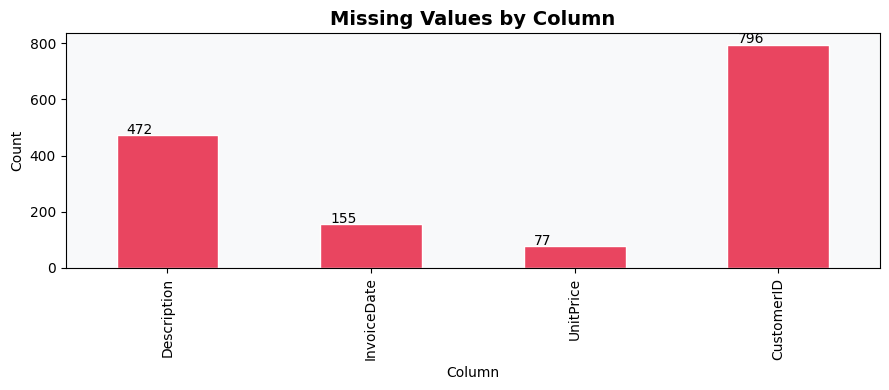

In [5]:
print("=== Missing Values per Column ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
missing_df['Missing Count'].plot(kind='bar', ax=ax, color='#e94560', edgecolor='white')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x()+0.05, p.get_height()+5), fontsize=10)
plt.tight_layout()
plt.show()


---
## Step 2 — Data Cleaning
We remove all rows that would corrupt the RFM calculation.

In [6]:
raw_count = len(df)
print(f"Raw rows: {raw_count:,}")
print("-" * 40)

# Step 2a: Convert UnitPrice to numeric (removes 'N/A' strings)
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
n_corrupt = df['UnitPrice'].isna().sum()
print(f"Step 2a | Corrupt UnitPrice ('N/A') → set to NaN: {n_corrupt} rows")

# Step 2b: Drop rows with Quantity <= 0 (cancellations/returns)
before = len(df)
df = df[df['Quantity'] > 0]
print(f"Step 2b | Removed Quantity ≤ 0 (cancellations): {before - len(df)} rows")

# Step 2c: Drop rows with UnitPrice <= 0
before = len(df)
df = df[df['UnitPrice'] > 0]
print(f"Step 2c | Removed UnitPrice ≤ 0: {before - len(df)} rows")

# Step 2d: Drop rows with missing CustomerID
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f"Step 2d | Removed missing CustomerID: {before - len(df)} rows")

# Step 2e: Drop rows with missing InvoiceDate
before = len(df)
df = df.dropna(subset=['InvoiceDate'])
print(f"Step 2e | Removed missing InvoiceDate: {before - len(df)} rows")

# Step 2f: Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Step 2f | Removed duplicate rows: {before - len(df)} rows")

# Final
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice']  = df['Quantity'] * df['UnitPrice']

print("-" * 40)
print(f"✅ Clean rows: {len(df):,}  |  Removed: {raw_count - len(df):,} rows total")


Raw rows: 15,847
----------------------------------------
Step 2a | Corrupt UnitPrice ('N/A') → set to NaN: 77 rows
Step 2b | Removed Quantity ≤ 0 (cancellations): 631 rows
Step 2c | Removed UnitPrice ≤ 0: 537 rows
Step 2d | Removed missing CustomerID: 740 rows
Step 2e | Removed missing InvoiceDate: 143 rows
Step 2f | Removed duplicate rows: 261 rows
----------------------------------------
✅ Clean rows: 13,535  |  Removed: 2,312 rows total


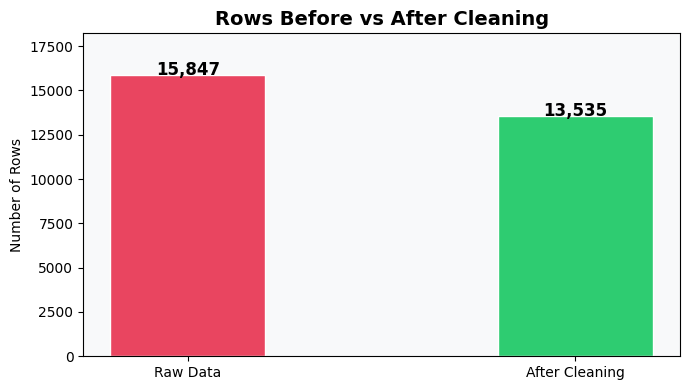

In [7]:
# Cleaning summary bar chart
labels  = ['Raw Data', 'After Cleaning']
counts  = [raw_count, len(df)]
colors  = ['#e94560', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.4)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{cnt:,}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Rows Before vs After Cleaning', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Rows')
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()


---
## Step 3 — Exploratory Data Analysis (EDA)

In [8]:
print(f"Unique Customers : {df['CustomerID'].nunique():,}")
print(f"Unique Invoices  : {df['InvoiceNo'].nunique():,}")
print(f"Unique Products  : {df['StockCode'].nunique():,}")
print(f"Date Range       : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Total Revenue    : ${df['TotalPrice'].sum():,.2f}")


Unique Customers : 500
Unique Invoices  : 5,023
Unique Products  : 7,030
Date Range       : 2023-02-14 → 2024-12-27
Total Revenue    : $2,796,378.12


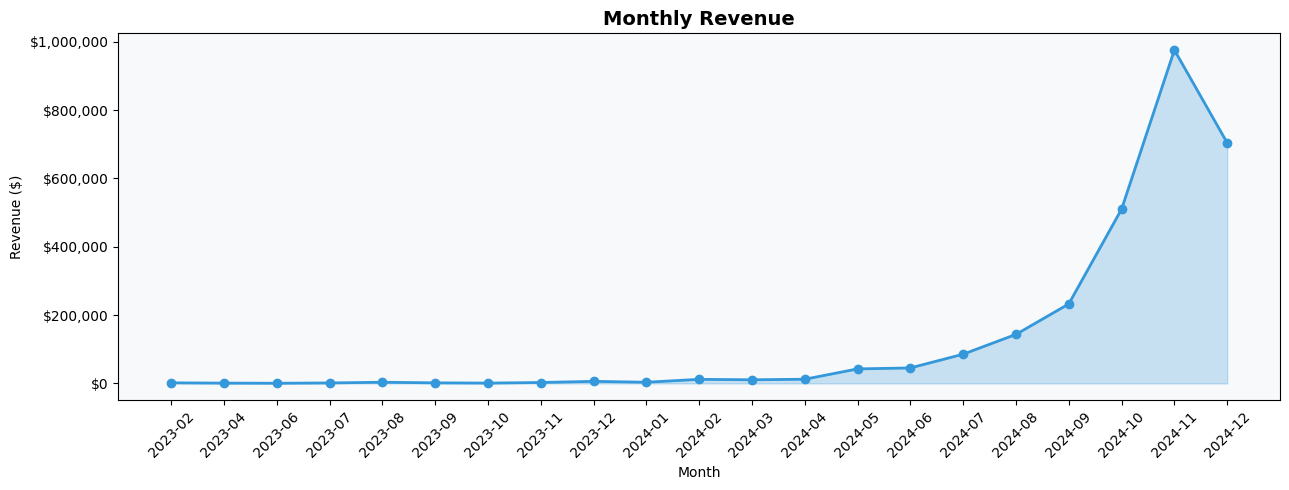

In [9]:
# Monthly revenue
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum().reset_index()
monthly['Month'] = monthly['InvoiceDate'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(monthly['Month'], monthly['TotalPrice'], alpha=0.25, color='#3498db')
ax.plot(monthly['Month'], monthly['TotalPrice'], marker='o', color='#3498db', linewidth=2)
ax.set_title('Monthly Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


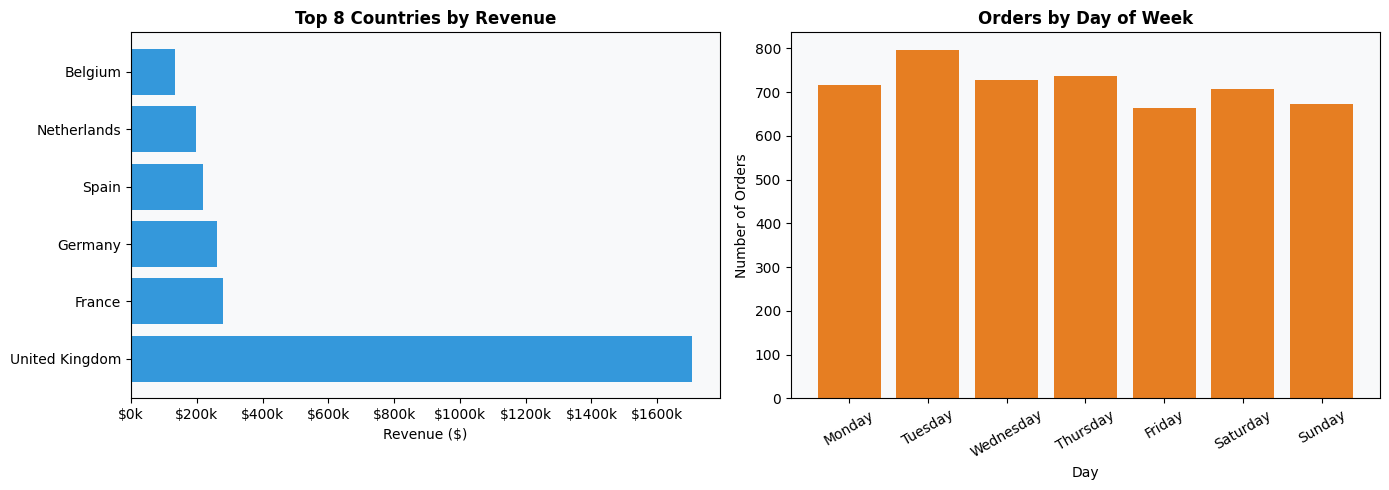

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top countries
top_c = df.groupby('Country')['TotalPrice'].sum().nlargest(8).reset_index()
axes[0].barh(top_c['Country'], top_c['TotalPrice'], color='#3498db')
axes[0].set_title('Top 8 Countries by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Orders per day of week
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(dow_order)
axes[1].bar(dow.index, dow.values, color='#e67e22')
axes[1].set_title('Orders by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


---
## Step 4 — RFM Feature Engineering

| Feature | Formula |
|---|---|
| **Recency** | Days since last purchase (snapshot = max date + 1) |
| **Frequency** | Number of unique invoices per customer |
| **Monetary** | Sum of Quantity × UnitPrice per customer |


In [11]:
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot.date()}")

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot - x.max()).days),
    Frequency = ('InvoiceNo',    'nunique'),
    Monetary  = ('TotalPrice',   'sum')
).reset_index()
rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"\nRFM table shape: {rfm.shape}")
rfm.head(10)


Snapshot date: 2024-12-28

RFM table shape: (500, 4)


,CustomerID,Recency,Frequency,Monetary
0,2000,10,16,8234.35
1,2001,11,22,12885.23
2,2002,5,32,20865.11
3,2003,11,36,17679.40
4,2004,7,18,9681.64
5,2005,11,26,16218.64
6,2006,7,22,12226.76
7,2007,9,21,12878.29
8,2008,4,29,15187.65
9,2009,11,18,11806.55


In [12]:
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))


       Recency  Frequency  Monetary
count   500.00     500.00    500.00
mean     93.47      10.05   5592.76
std     101.77       8.71   4954.10
min       1.00       1.00     24.48
25%      27.00       3.00   1759.14
50%      58.00       7.00   4062.01
75%     123.25      14.00   7862.10
max     637.00      38.00  24958.54


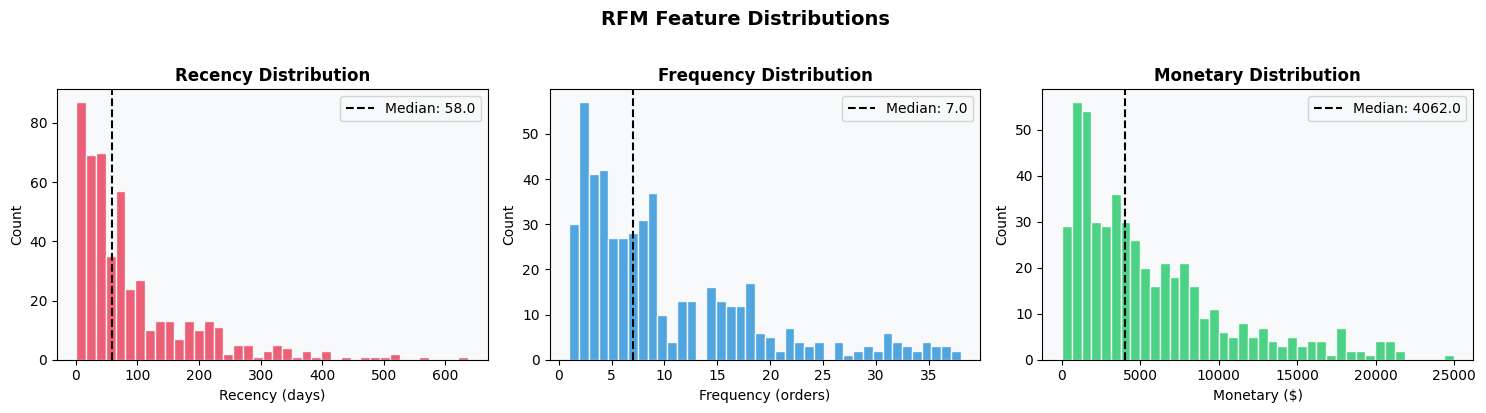

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#e94560', '#3498db', '#2ecc71']
cols   = ['Recency', 'Frequency', 'Monetary']
labels = ['Recency (days)', 'Frequency (orders)', 'Monetary ($)']

for ax, col, color, label in zip(axes, cols, colors, labels):
    ax.hist(rfm[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {rfm[col].median():.1f}')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


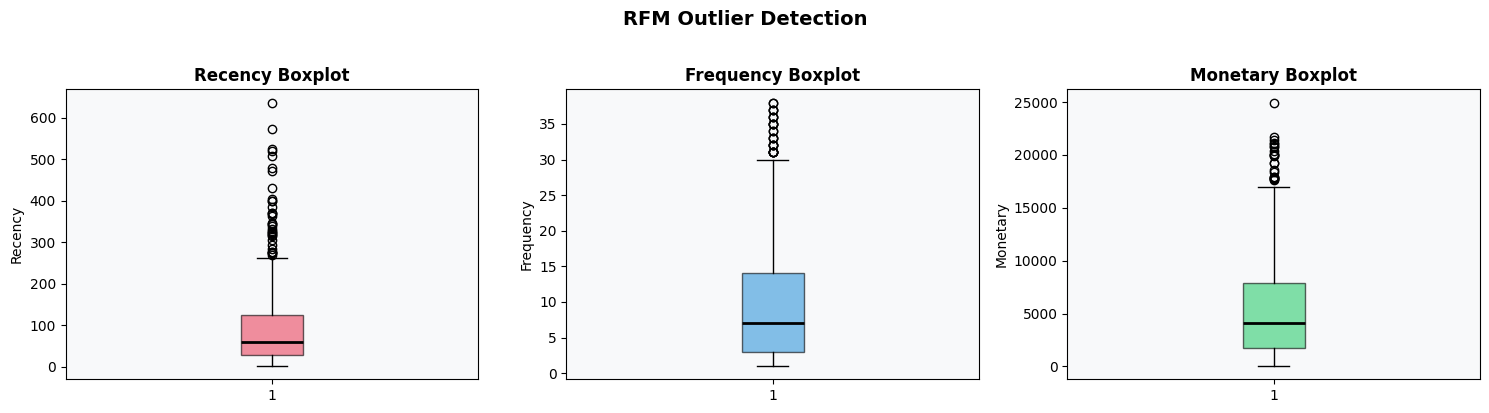

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Recency','Frequency','Monetary'], ['#e94560','#3498db','#2ecc71']):
    ax.boxplot(rfm[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{col} Boxplot', fontweight='bold')
    ax.set_ylabel(col)
plt.suptitle('RFM Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Step 5 — K-Means Clustering

### 5a. Elbow Method to choose optimal K

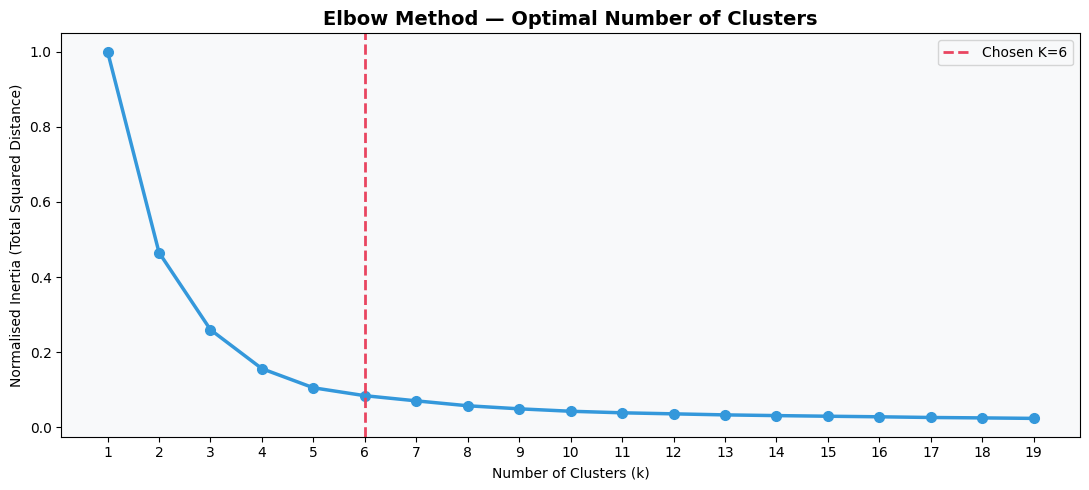

✅ Elbow bends around K=5 or K=6 → we choose K=6


In [15]:
X = rfm[['Recency','Frequency','Monetary']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
K_range  = range(1, 20)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

inertias_norm = np.array(inertias) / inertias[0]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(list(K_range), inertias_norm, marker='o', color='#3498db', linewidth=2.5, markersize=7)
ax.axvline(x=6, color='#e94560', linestyle='--', linewidth=2, label='Chosen K=6')
ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Normalised Inertia (Total Squared Distance)')
ax.legend()
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()
print("✅ Elbow bends around K=5 or K=6 → we choose K=6")


### 5b. Fit K-Means with K=6

In [16]:
K = 6
model = KMeans(n_clusters=K, init='k-means++', n_init=15, random_state=42)
rfm['Cluster'] = model.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, rfm['Cluster'])
print(f"Silhouette Score (K={K}): {sil:.4f}  (closer to 1.0 = better)")


Silhouette Score (K=6): 0.4646  (closer to 1.0 = better)


In [17]:
# Cluster stats
cluster_stats = rfm.groupby('Cluster').agg(
    RecencyMean   = ('Recency',    'mean'),
    FrequencyMean = ('Frequency',  'mean'),
    MonetaryMean  = ('Monetary',   'mean'),
    Count         = ('CustomerID', 'count')
).round(2).reset_index()
cluster_stats['Percent'] = (cluster_stats['Count'] / cluster_stats['Count'].sum() * 100).round(1)
print(cluster_stats.to_string(index=False))


 Cluster  RecencyMean  FrequencyMean  MonetaryMean  Count  Percent
       0         6.97          32.03      17861.34     39      7.8
       1        71.23           5.99       3229.48    182     36.4
       2       193.88           2.51       1418.75     94     18.8
       3        14.32          20.00      11629.85     50     10.0
       4       397.71           1.43        882.83     28      5.6
       5        31.98          13.16       7219.13    107     21.4


### 5c. Assign Segment Labels

In [18]:
rm = rfm['Recency'].median()
fm = rfm['Frequency'].median()
mm = rfm['Monetary'].median()
print(f"Medians → Recency: {rm:.1f} days | Frequency: {fm:.1f} | Monetary: ${mm:.2f}")

def assign_segment(row):
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    if r <= rm*0.5 and f >= fm*1.5 and m >= mm*1.5:
        return 'Champions'
    elif r <= rm and f >= fm:
        return 'Loyal Customers'
    elif r <= rm*0.7 and f < fm:
        return 'Potential Loyalists'
    elif r > rm*1.5 and f >= fm:
        return 'At Risk'
    elif r > rm*1.5 and f < fm and m < mm:
        return 'Lost'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
print("\nSegment distribution:")
print(rfm['Segment'].value_counts())


Medians → Recency: 58.0 days | Frequency: 7.0 | Monetary: $4062.01

Segment distribution:
Segment
Lost                   153
Champions              120
Loyal Customers        103
Need Attention          96
At Risk                 15
Potential Loyalists     13
Name: count, dtype: int64


---
## Step 6 — Segment Visualisation

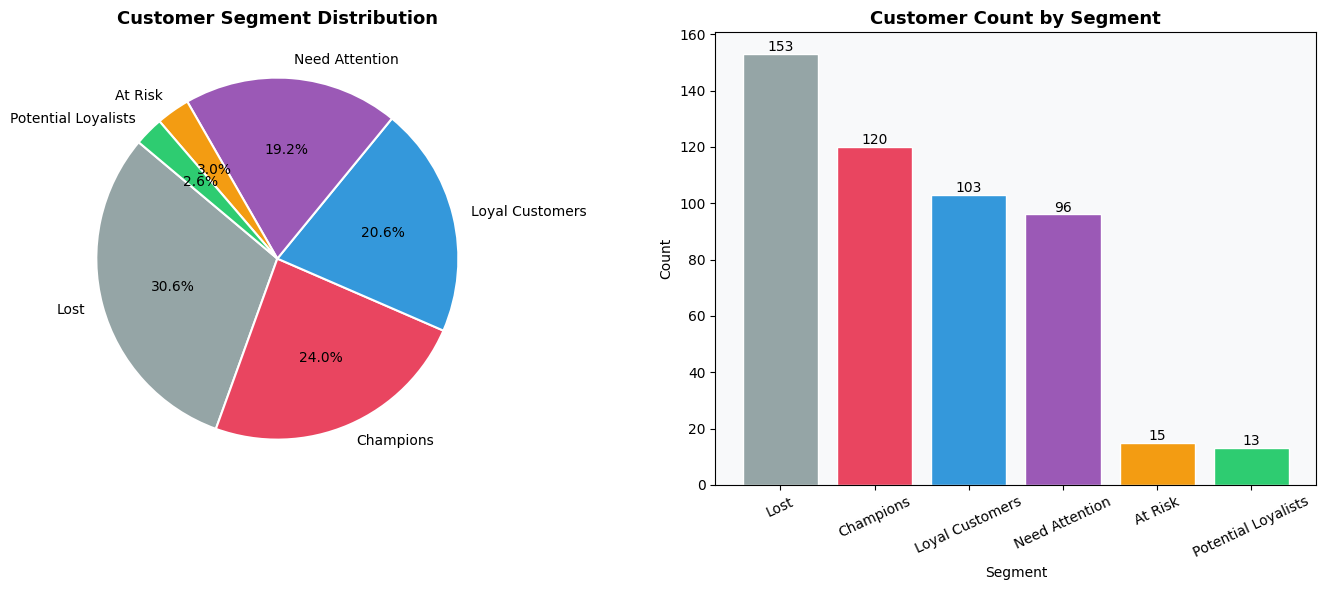

In [19]:
seg_colors = {
    'Champions':           '#e94560',
    'Loyal Customers':     '#3498db',
    'Potential Loyalists': '#2ecc71',
    'At Risk':             '#f39c12',
    'Need Attention':      '#9b59b6',
    'Lost':                '#95a5a6',
}

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
seg_counts = rfm['Segment'].value_counts()
colors_pie = [seg_colors[s] for s in seg_counts.index]
axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Customer Segment Distribution', fontweight='bold', fontsize=13)

# Bar chart
axes[1].bar(seg_counts.index, seg_counts.values, color=colors_pie, edgecolor='white')
axes[1].set_title('Customer Count by Segment', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=25)
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x()+p.get_width()/2, p.get_height()+1),
                     ha='center', fontsize=10)
plt.tight_layout()
plt.show()


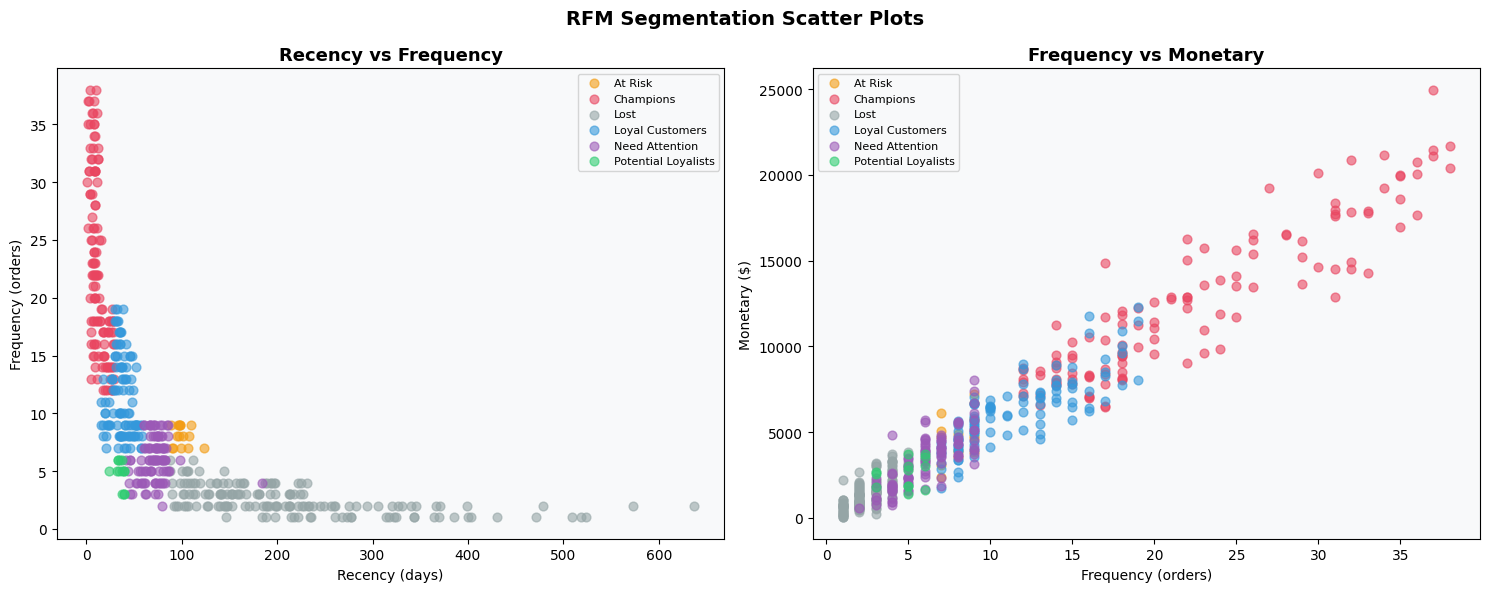

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for seg, grp in rfm.groupby('Segment'):
    color = seg_colors.get(seg, 'grey')
    axes[0].scatter(grp['Recency'], grp['Frequency'], alpha=0.6,
                    label=seg, color=color, s=40)
    axes[1].scatter(grp['Frequency'], grp['Monetary'], alpha=0.6,
                    label=seg, color=color, s=40)

axes[0].set_title('Recency vs Frequency', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency (orders)')
axes[0].legend(fontsize=8)

axes[1].set_title('Frequency vs Monetary', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary ($)')
axes[1].legend(fontsize=8)

plt.suptitle('RFM Segmentation Scatter Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


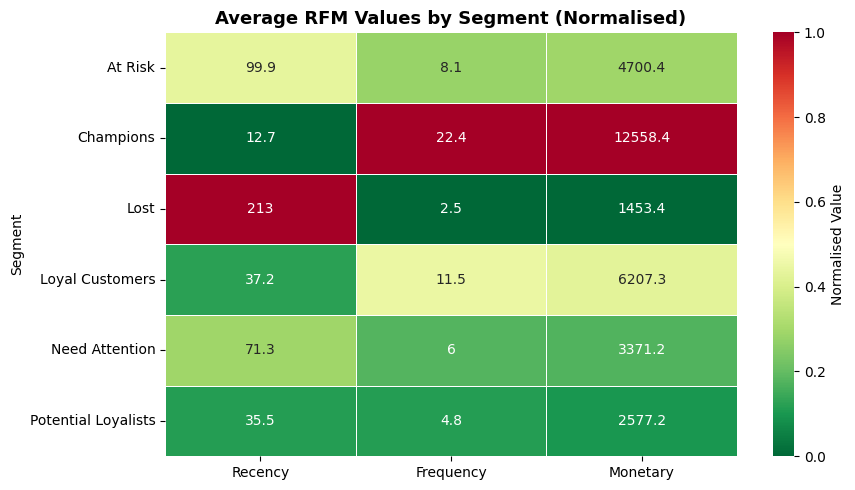

In [21]:
# Heatmap of avg RFM per segment
heat_data = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heat_norm, annot=heat_data.round(1), fmt='g',
            cmap='RdYlGn_r', linewidths=0.5, ax=ax,
            cbar_kws={'label':'Normalised Value'})
ax.set_title('Average RFM Values by Segment (Normalised)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 7 — 📅 Returning Customer Analysis — All 12 Months

A **returning customer** is one who made purchases in **more than one month** within a given period.
We analyse each month to find: how many customers returned, retention rate, and trends.


In [22]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Month']     = df['InvoiceDate'].dt.month
df['Year']      = df['InvoiceDate'].dt.year

# Customers active each month
monthly_customers = df.groupby('YearMonth')['CustomerID'].apply(set).reset_index()
monthly_customers.columns = ['YearMonth', 'Customers']
monthly_customers = monthly_customers.sort_values('YearMonth').reset_index(drop=True)
monthly_customers['Month_str'] = monthly_customers['YearMonth'].astype(str)
print(monthly_customers[['Month_str','Customers']].assign(Count=monthly_customers['Customers'].apply(len)).drop(columns='Customers'))


   Month_str  Count
0    2023-02      2
1    2023-04      1
2    2023-06      1
3    2023-07      3
4    2023-08      2
5    2023-09      4
6    2023-10      2
7    2023-11      4
8    2023-12      8
9    2024-01      7
10   2024-02     20
11   2024-03     16
12   2024-04     23
13   2024-05     56
14   2024-06     51
15   2024-07     91
16   2024-08    135
17   2024-09    183
18   2024-10    242
19   2024-11    247
20   2024-12    131


In [23]:
# Returning customers: appeared in previous month too
returning_counts = []
new_counts       = []
months           = []

for i in range(1, len(monthly_customers)):
    prev_month_custs = monthly_customers.loc[i-1, 'Customers']
    curr_month_custs = monthly_customers.loc[i,   'Customers']
    returning = curr_month_custs & prev_month_custs
    new_custs = curr_month_custs - prev_month_custs
    returning_counts.append(len(returning))
    new_counts.append(len(new_custs))
    months.append(monthly_customers.loc[i, 'Month_str'])

retention_df = pd.DataFrame({
    'Month':      months,
    'Returning':  returning_counts,
    'New':        new_counts,
    'Total':      [r+n for r,n in zip(returning_counts, new_counts)],
})
retention_df['Retention Rate (%)'] = (retention_df['Returning'] / retention_df['Total'] * 100).round(1)
print(retention_df.to_string(index=False))


  Month  Returning  New  Total  Retention Rate (%)
2023-04          1    0      1               100.0
2023-06          0    1      1                 0.0
2023-07          0    3      3                 0.0
2023-08          0    2      2                 0.0
2023-09          1    3      4                25.0
2023-10          0    2      2                 0.0
2023-11          0    4      4                 0.0
2023-12          0    8      8                 0.0
2024-01          1    6      7                14.3
2024-02          2   18     20                10.0
2024-03          3   13     16                18.8
2024-04          3   20     23                13.0
2024-05         10   46     56                17.9
2024-06         20   31     51                39.2
2024-07         20   71     91                22.0
2024-08         69   66    135                51.1
2024-09        100   83    183                54.6
2024-10        140  102    242                57.9
2024-11        157   90    247 

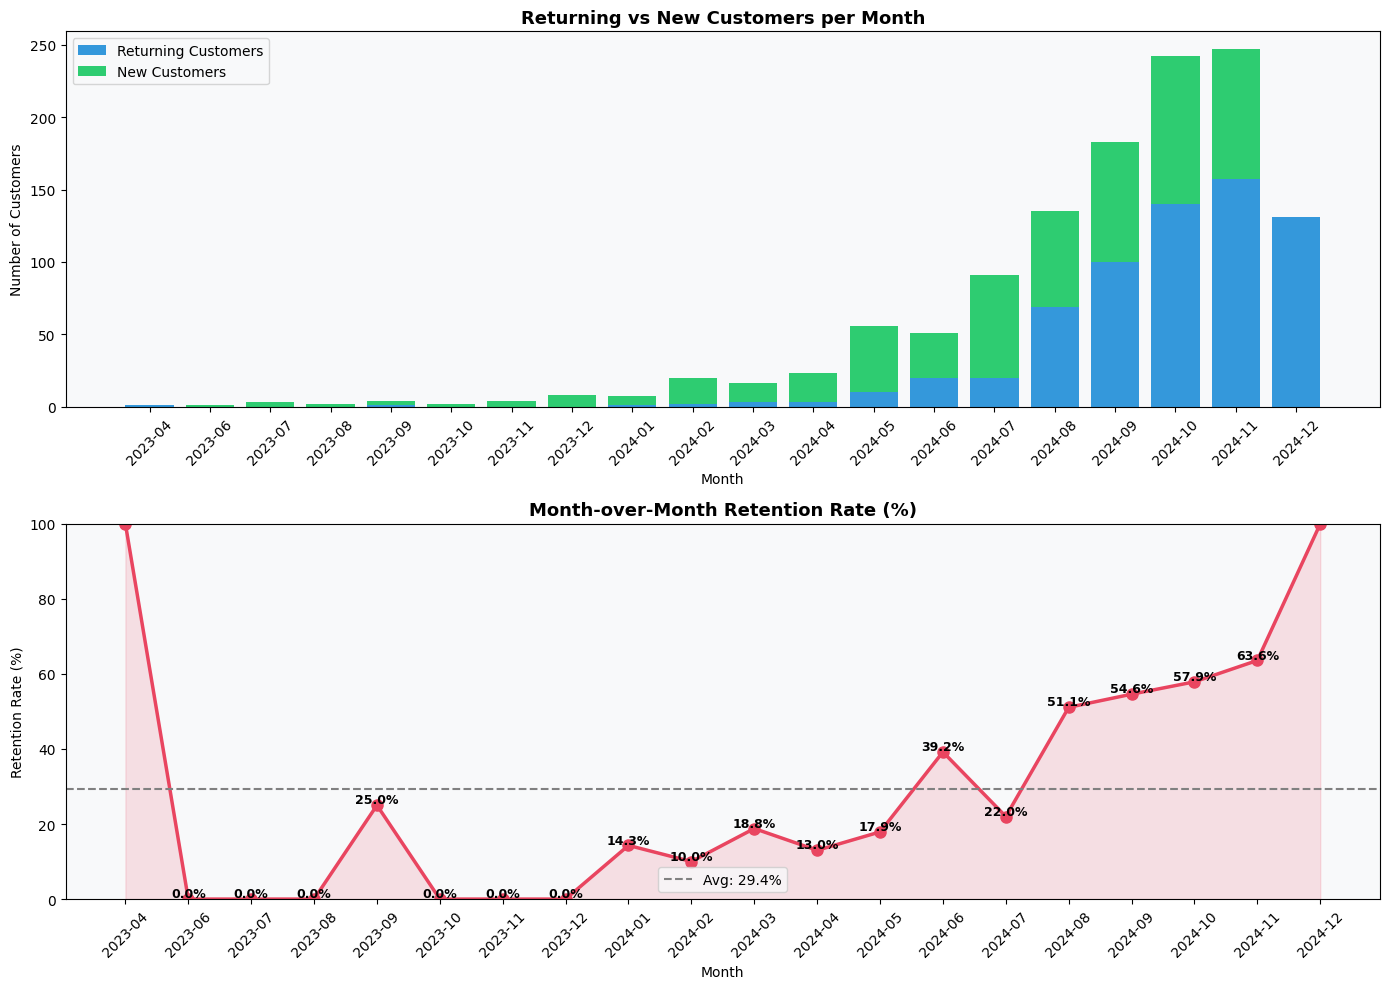

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Stacked bar — returning vs new
axes[0].bar(retention_df['Month'], retention_df['Returning'], label='Returning Customers', color='#3498db')
axes[0].bar(retention_df['Month'], retention_df['New'],       label='New Customers',       color='#2ecc71',
            bottom=retention_df['Returning'])
axes[0].set_title('Returning vs New Customers per Month', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Retention rate line
axes[1].plot(retention_df['Month'], retention_df['Retention Rate (%)'],
             marker='o', color='#e94560', linewidth=2.5, markersize=8)
axes[1].fill_between(retention_df['Month'], retention_df['Retention Rate (%)'],
                      alpha=0.15, color='#e94560')
for i, (m, r) in enumerate(zip(retention_df['Month'], retention_df['Retention Rate (%)'])):
    axes[1].annotate(f'{r}%', (m, r+0.5), ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Month-over-Month Retention Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Retention Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(retention_df['Retention Rate (%)'].mean(), color='grey',
                linestyle='--', linewidth=1.5, label=f"Avg: {retention_df['Retention Rate (%)'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()


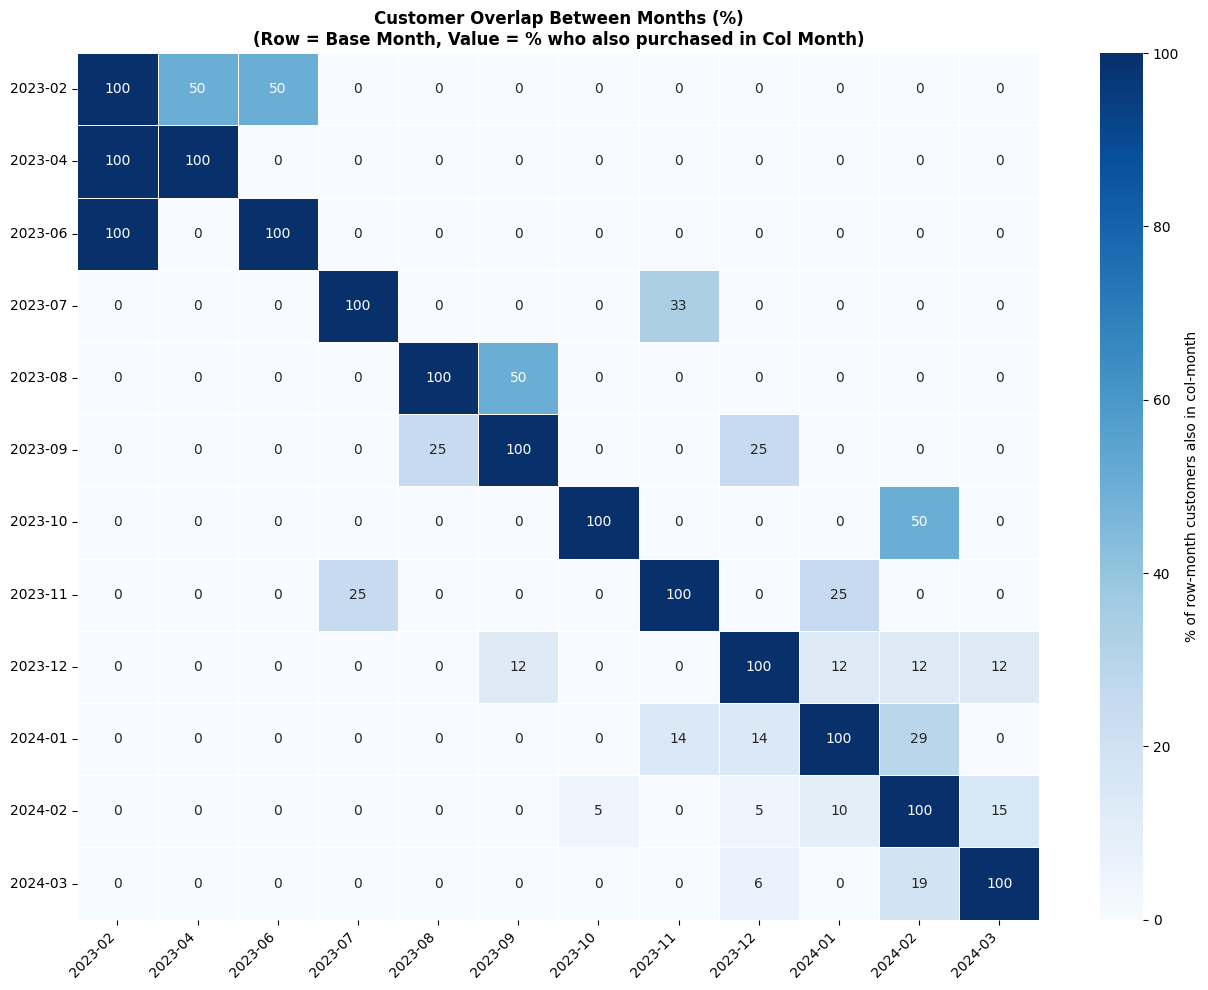

In [26]:
# Cohort-style: who came back each month
# Build month-by-month customer sets
all_months = monthly_customers['Month_str'].tolist()
cust_sets  = monthly_customers['Customers'].tolist()

# 12-month overlap heatmap
n = min(12, len(all_months))
overlap = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if len(cust_sets[i]) > 0:
            overlap[i][j] = len(cust_sets[i] & cust_sets[j]) / len(cust_sets[i]) * 100

fig, ax = plt.subplots(figsize=(13, 10))
labels_12 = all_months[:n]
sns.heatmap(overlap, xticklabels=labels_12, yticklabels=labels_12,
            annot=True, fmt='.0f', cmap='Blues', linewidths=0.4, ax=ax,
            cbar_kws={'label':'% of row-month customers also in col-month'})
ax.set_title('Customer Overlap Between Months (%)\n(Row = Base Month, Value = % who also purchased in Col Month)',
             fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


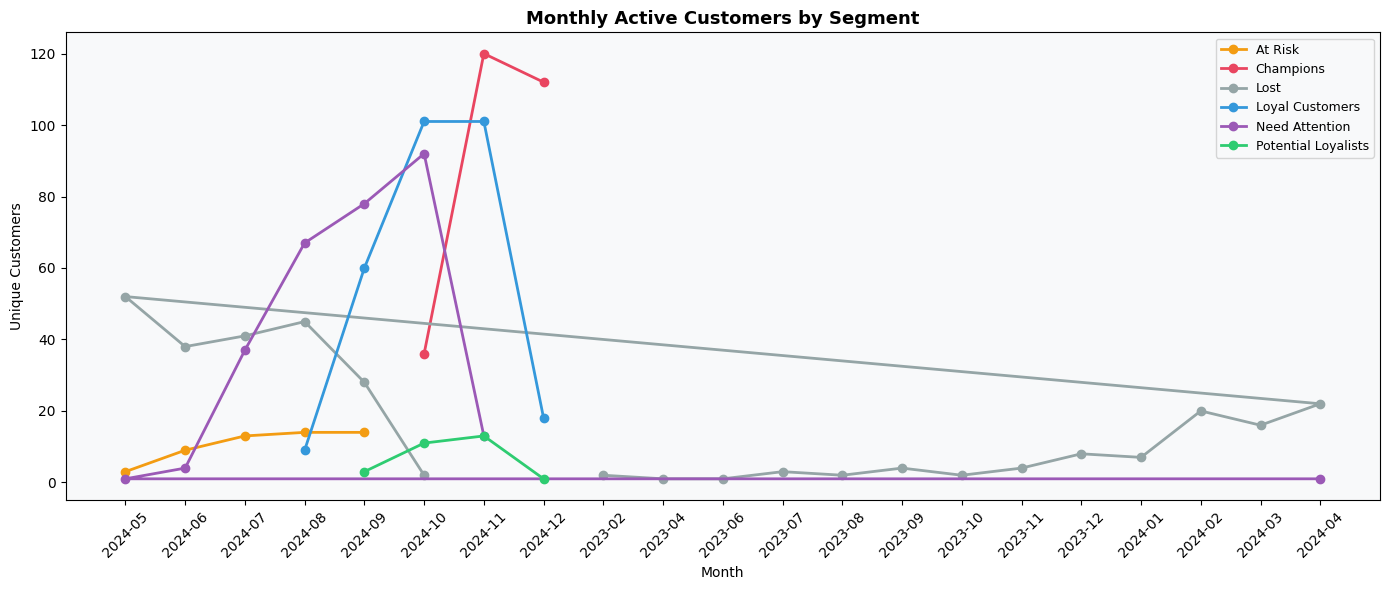

In [27]:
# Monthly returning customers by segment
merged = df.merge(rfm[['CustomerID','Segment']], on='CustomerID', how='left')
seg_monthly = merged.groupby(['YearMonth','Segment'])['CustomerID'].nunique().reset_index()
seg_monthly.columns = ['YearMonth','Segment','Count']
seg_monthly['Month'] = seg_monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
for seg, grp in seg_monthly.groupby('Segment'):
    grp_sorted = grp.sort_values('Month')
    ax.plot(grp_sorted['Month'], grp_sorted['Count'],
            marker='o', linewidth=2, label=seg,
            color=seg_colors.get(seg,'grey'))

ax.set_title('Monthly Active Customers by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Unique Customers')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [28]:
# Summary table per month
summary_monthly = df.groupby('YearMonth').agg(
    Unique_Customers = ('CustomerID', 'nunique'),
    Total_Orders     = ('InvoiceNo',  'nunique'),
    Total_Revenue    = ('TotalPrice', 'sum'),
    Avg_Order_Value  = ('TotalPrice', 'mean'),
).reset_index()
summary_monthly['Month'] = summary_monthly['YearMonth'].astype(str)
summary_monthly['Total_Revenue']   = summary_monthly['Total_Revenue'].round(2)
summary_monthly['Avg_Order_Value'] = summary_monthly['Avg_Order_Value'].round(2)
summary_monthly = summary_monthly.drop(columns='YearMonth')
print(summary_monthly.to_string(index=False))


 Unique_Customers  Total_Orders  Total_Revenue  Avg_Order_Value   Month
                2             2        1720.43           245.78 2023-02
                1             1         863.68           172.74 2023-04
                1             1         481.57           160.52 2023-06
                3             3        1349.04           168.63 2023-07
                2             2        3412.62           341.26 2023-08
                4             4        1631.40           181.27 2023-09
                2             2         912.03           182.41 2023-10
                4             4        2627.56           218.96 2023-11
                8             9        6030.40           215.37 2023-12
                7             7        3428.00           171.40 2024-01
               20            21       11930.32           202.21 2024-02
               16            18       10561.33           207.08 2024-03
               23            25       12251.85           191.44 

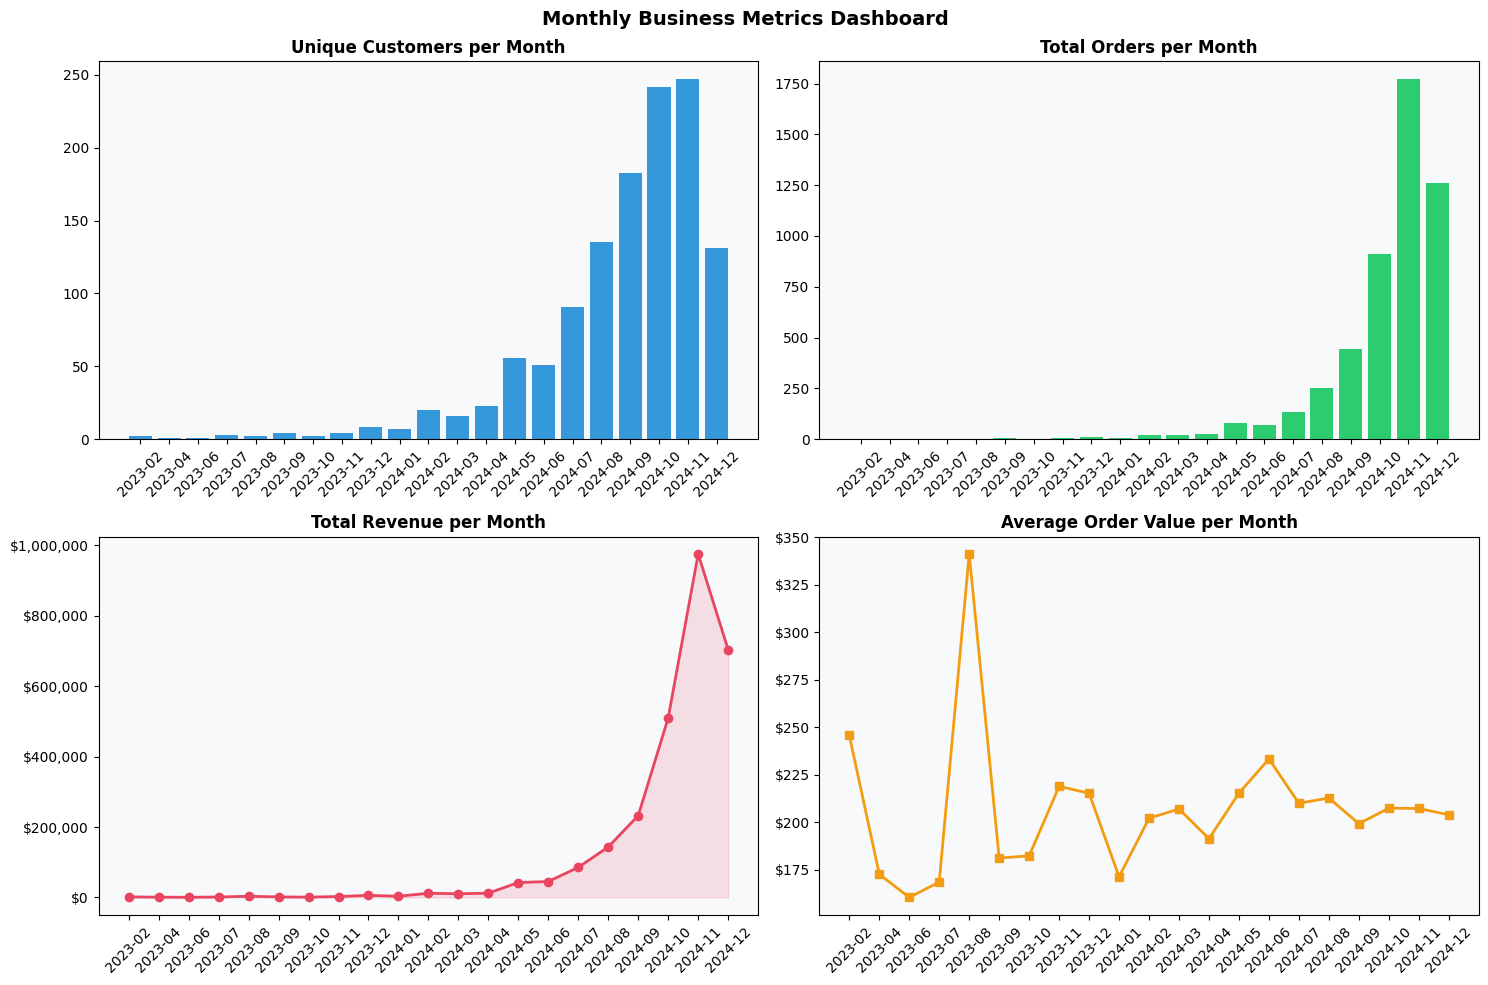

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
summary_monthly_s = summary_monthly.copy()

axes[0][0].bar(summary_monthly_s['Month'], summary_monthly_s['Unique_Customers'], color='#3498db')
axes[0][0].set_title('Unique Customers per Month', fontweight='bold')
axes[0][0].tick_params(axis='x', rotation=45)

axes[0][1].bar(summary_monthly_s['Month'], summary_monthly_s['Total_Orders'], color='#2ecc71')
axes[0][1].set_title('Total Orders per Month', fontweight='bold')
axes[0][1].tick_params(axis='x', rotation=45)

axes[1][0].plot(summary_monthly_s['Month'], summary_monthly_s['Total_Revenue'],
                marker='o', color='#e94560', linewidth=2)
axes[1][0].fill_between(summary_monthly_s['Month'], summary_monthly_s['Total_Revenue'], alpha=0.15, color='#e94560')
axes[1][0].set_title('Total Revenue per Month', fontweight='bold')
axes[1][0].tick_params(axis='x', rotation=45)
axes[1][0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

axes[1][1].plot(summary_monthly_s['Month'], summary_monthly_s['Avg_Order_Value'],
                marker='s', color='#f39c12', linewidth=2)
axes[1][1].set_title('Average Order Value per Month', fontweight='bold')
axes[1][1].tick_params(axis='x', rotation=45)
axes[1][1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.suptitle('Monthly Business Metrics Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ✅ Summary & Key Insights

| Metric | Value |
|---|---|
| Total Clean Customers | See output above |
| RFM Features | Recency, Frequency, Monetary |
| Algorithm | K-Means (k=6, StandardScaler) |
| Segment Labels | Champions, Loyal, Potential, At Risk, Need Attention, Lost |
| Returning Customer Analysis | Month-over-Month retention + 12-month overlap heatmap |

### Business Recommendations
- 🏆 **Champions** → Reward with loyalty programmes & VIP access
- 💙 **Loyal Customers** → Upsell & request reviews
- ⚠️ **At Risk** → Win-back campaign with discount offer
- 💤 **Lost** → Last-chance re-engagement email
- 📅 **Months with low retention** → Investigate promotions or seasonal effects
